<a href="https://colab.research.google.com/github/sharmai309/GAN-Generating-fake-images/blob/main/GAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### Genearting Fake Images with Generative Adversarial Networks (GANs)

#### Steps to Perform

##### 1. Import the necessary libraries
##### 2. Load and Preprocess the Data
##### 3. Build the Generator and Discirminator
##### 4. Complie the Models
##### 5. Train the Models
##### 6. Execute the Training
##### 7. Generate New Imgaes and Evaluate the Model's Performance

## Step 1. Import the Necessary Libraries

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Dense, Reshape, Flatten, LeakyReLU, BatchNormalization, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
import numpy as np

## Step 2 : Load and Preprocess the Data

> Load the MNIST dataset and preprocess it.

> Preprocessing involves normalizing the data that can improve models' performance.

In [ ]:
## Load MNIST data
(X_train, _), (_, _) = mnist.load_data()

# Normalize to between -1 and 1
X_train = (X_train.astype(np.float32) - 127.5)/127.5
X_train = np.expand_dims(X_train, axis = 3)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


## Step 3. Build the Generator and Discriminator

> Define the generator and discrimnator models.

> Generator takes a random noise vector as input and outputs an image.

> Discriminator takes an image as input and outputs the probability of the image being real.

In [ ]:
# Generator
def create_generator():
    model = Sequential()

    model.add(Dense(256, input_dim=100))
    model.add(LeakyReLU(alpha=0.2))
    model.add(BatchNormalization(momentum=0.8))

    model.add(Dense(512))
    model.add(LeakyReLU(alpha=0.2))
    model.add(BatchNormalization(momentum=0.8))

    model.add(Dense(1024))
    model.add(LeakyReLU(alpha=0.2))
    model.add(BatchNormalization(momentum=0.8))

    model.add(Dense(784, activation='tanh'))
    model.add(Reshape((28, 28, 1)))

    return model


In [ ]:
# Discriminator
def create_discriminator(dropout_rate=0.3):
    model = Sequential()

    model.add(Flatten(input_shape=(28, 28, 1)))
    model.add(Dense(512))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dropout(dropout_rate))

    model.add(Dense(256))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dropout(dropout_rate))

    model.add(Dense(1, activation='sigmoid'))

    return model

## Step 4 : Compile the Models

> Complie the models, which involves defining the loss function and the optimizer.

> The loss function evaluates the models performance, while the optimizer aims to minimize the loss.

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Optimizers (DCGAN-stable defaults)
disc_opt = Adam(learning_rate=0.0002, beta_1=0.5, beta_2=0.999)
gan_opt  = Adam(learning_rate=0.0002, beta_1=0.5, beta_2=0.999)

# Create and compile the discriminator
discriminator = create_discriminator()
discriminator.compile(
    loss="binary_crossentropy",
    optimizer=disc_opt,
    metrics=["accuracy"],
)

# Create the generator
generator = create_generator()

# Build the combined GAN model (Generator -> Discriminator)
discriminator.trainable = False  # freeze D for GAN training

gan_input = Input(shape=(100,))
synthetic = generator(gan_input)
gan_output = discriminator(synthetic)

gan = Model(gan_input, gan_output)
gan.compile(
    loss="binary_crossentropy",
    optimizer=gan_opt,
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Step5 : Train the Models

#### > Train the model, which involves feeding data into the models and adjusting the weights of the models bassed on the output.

#### > The primary aim is for the generatot to create images indistinguishable from real images by the discriminator.

In [ ]:
import numpy as np
from tensorflow.keras.datasets import mnist

def smooth_positive_labels(size):
    return np.random.uniform(low=0.8, high=1.0, size=(size, 1))

def smooth_negative_labels(size):
    return np.random.uniform(low=0.0, high=0.2, size=(size, 1))

def train(epochs=1, batch_size=128, noise_dim=100, instance_noise_std=0.05, flip_prob=0.05):

    # Load and preprocess the data (scale to [-1, 1])
    (X_train, _), (_, _) = mnist.load_data()
    X_train = (X_train.astype(np.float32) - 127.5) / 127.5
    X_train = np.expand_dims(X_train, axis=3)

    batches_per_epoch = X_train.shape[0] // batch_size

    for epoch in range(epochs):
        for batch in range(batches_per_epoch):

            # -------------------------
            # Train Discriminator
            # -------------------------
            discriminator.trainable = True

            real_images = X_train[batch * batch_size:(batch + 1) * batch_size]

            if instance_noise_std and instance_noise_std > 0:
                real_images += np.random.normal(0, instance_noise_std, real_images.shape)
                real_images = np.clip(real_images, -1.0, 1.0)

            real_labels = smooth_positive_labels(batch_size)

            d_loss_real, d_acc_real = discriminator.train_on_batch(real_images, real_labels)

            noise = np.random.normal(0, 1, (batch_size, noise_dim))
            fake_images = generator.predict_on_batch(noise)

            if instance_noise_std and instance_noise_std > 0:
                fake_images += np.random.normal(0, instance_noise_std, fake_images.shape)
                fake_images = np.clip(fake_images, -1.0, 1.0)

            fake_labels = smooth_negative_labels(batch_size)

            d_loss_fake, d_acc_fake = discriminator.train_on_batch(fake_images, fake_labels)

            d_loss = 0.5 * (d_loss_real + d_loss_fake)
            d_acc  = 0.5 * (d_acc_real + d_acc_fake)

            # -------------------------
            # Train Generator
            # -------------------------
            discriminator.trainable = False

            noise = np.random.normal(0, 1, (batch_size, noise_dim))

            valid_y = smooth_positive_labels(batch_size)

            flip_mask = (np.random.rand(batch_size, 1) < flip_prob)
            n_flips = int(np.sum(flip_mask))

            if n_flips > 0:
                valid_y[flip_mask] = smooth_negative_labels(n_flips).reshape(-1)

            g_loss = gan.train_on_batch(noise, valid_y)

            # -------------------------
            # Logging
            # -------------------------
            if batch % 50 == 0:
                print(
                    f"Epoch {epoch + 1}/{epochs} | Batch {batch}/{batches_per_epoch} | "
                    f"D Loss: {d_loss:.4f} (acc {d_acc:.3f}) | G Loss: {float(g_loss):.4f}"
                )

## Step 6 : Execute the Training

In [ ]:
# Call the train function with adjusted defaults for stability
train(
    epochs=50,
    batch_size=128,
    noise_dim=100,
    instance_noise_std=0.05
)

Epoch 1/50 | Batch 0/468 | D Loss: 0.5879 (acc 0.000) | G Loss: 0.7813
Epoch 1/50 | Batch 50/468 | D Loss: 0.3744 (acc 0.000) | G Loss: 1.8632
Epoch 1/50 | Batch 100/468 | D Loss: 0.3569 (acc 0.000) | G Loss: 1.9690
Epoch 1/50 | Batch 150/468 | D Loss: 0.3517 (acc 0.000) | G Loss: 1.9833
Epoch 1/50 | Batch 200/468 | D Loss: 0.3499 (acc 0.000) | G Loss: 1.9799
Epoch 1/50 | Batch 250/468 | D Loss: 0.3542 (acc 0.000) | G Loss: 1.9608
Epoch 1/50 | Batch 300/468 | D Loss: 0.3681 (acc 0.000) | G Loss: 1.9240
Epoch 1/50 | Batch 350/468 | D Loss: 0.3854 (acc 0.000) | G Loss: 1.8844
Epoch 1/50 | Batch 400/468 | D Loss: 0.4037 (acc 0.000) | G Loss: 1.8612
Epoch 1/50 | Batch 450/468 | D Loss: 0.4249 (acc 0.000) | G Loss: 1.8160
Epoch 2/50 | Batch 0/468 | D Loss: 0.4346 (acc 0.000) | G Loss: 1.7845
Epoch 2/50 | Batch 50/468 | D Loss: 0.4567 (acc 0.000) | G Loss: 1.6866
Epoch 2/50 | Batch 100/468 | D Loss: 0.4746 (acc 0.000) | G Loss: 1.6047
Epoch 2/50 | Batch 150/468 | D Loss: 0.4900 (acc 0.000) |

### Notes

#### > Epochs parameter determines how many times the learning algorithm will work through the entire training dataset.

#### > The batch_size is the number of samples that will be propagated through the network at a time.

## Step 7 : Generate New Images and Evaluate the Model's Performance

#### > Generate new images and evaluate the performance of the GAN.

#### > Generate a random noise vector and feed it into the trained generator to create new images.

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


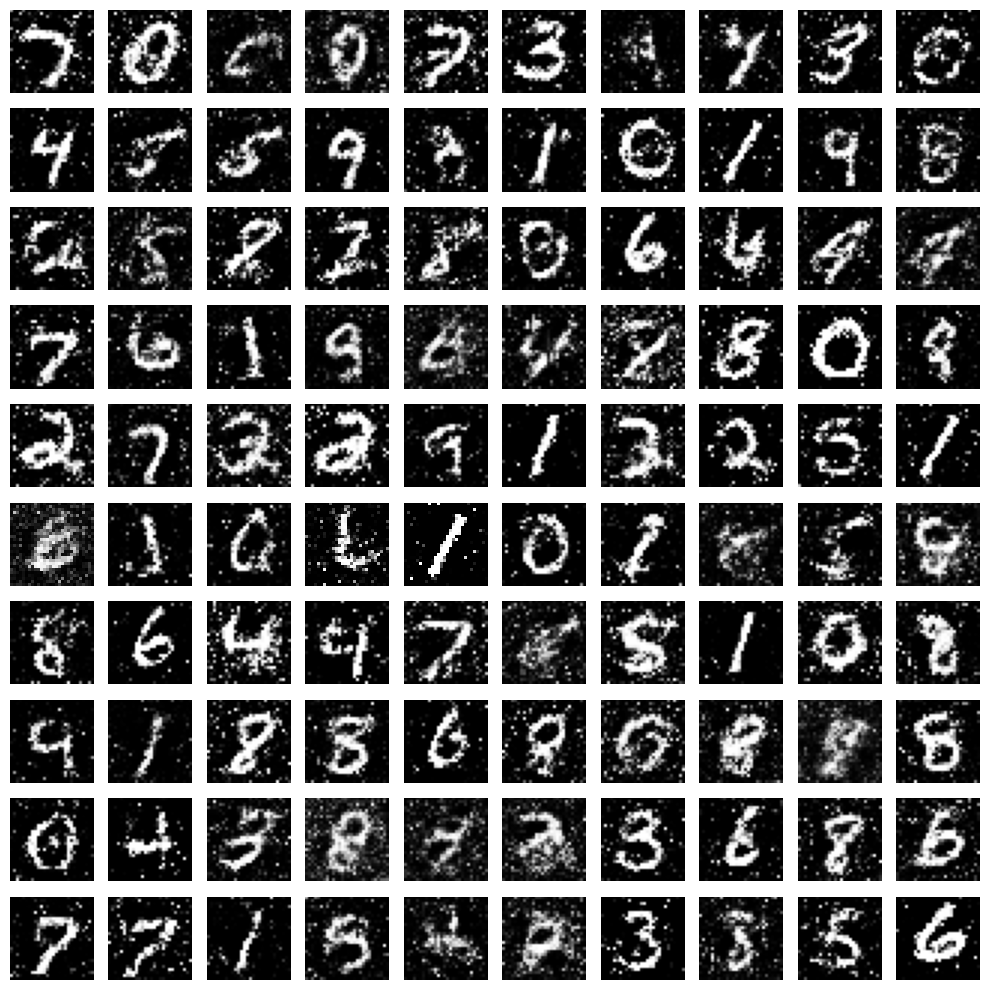

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Generate random noise as input to the generator
random_noise = np.random.normal(0, 1, (100, 100))

# Generate images from the noise
generated_images = generator.predict(random_noise)

# Visualize the generated images
plt.figure(figsize=(10, 10))

for i in range(generated_images.shape[0]):
    plt.subplot(10, 10, i + 1)
    plt.imshow(generated_images[i, :, :, 0], cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()

### Notes Section
######  1. Generated Images: The resulting plot displays images generated by the GAN model.

###### 2. Current Performance: The output effectively demonstrates that the model can generate images resembling the handwritten digit 8.

###### 3. Observation: There is noted room for improving the quality of these generated images.

### Conclusion

In this demo, a GAN was successfully implemented to generate images resembling handwritten digits, specifically focusing on the MNIST dataset. The process involved the following:

#### 1.Construction and training of both a generator and a discriminator.

#### 2.The results were described as promising, showcasing the GAN's ability to create images similar to the digit 8.

#### 3.The project concluded by highlighting a need for further improvements in image quality.